<a href="https://colab.research.google.com/github/Rohith2108/DAA/blob/main/DAA10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---------------------------------------------------------------------------
Input Type            DQS Comps   DQS Time(ms)      RQS Comps   RQS Time(ms)
---------------------------------------------------------------------------
Random                    67475          13.51          68571          16.40
Sorted                 12497500        3572.19          68635          34.00
Reverse                12497500        5750.50          75570          14.95
Nearly Sorted            150264          25.48          68773          13.52


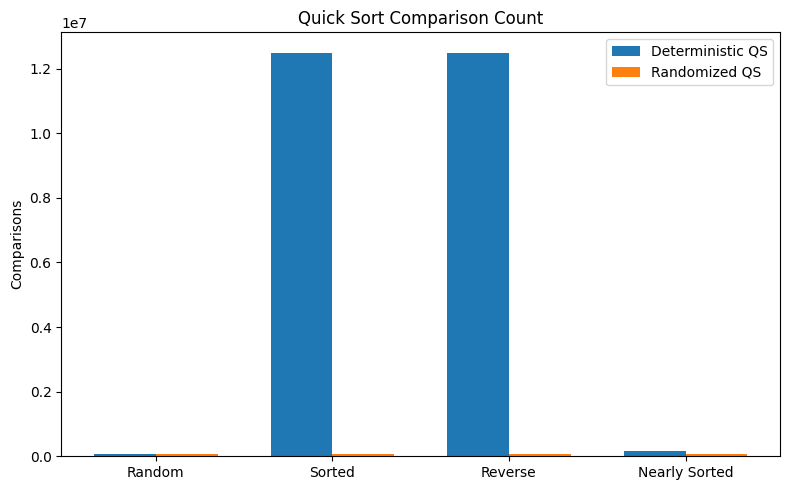

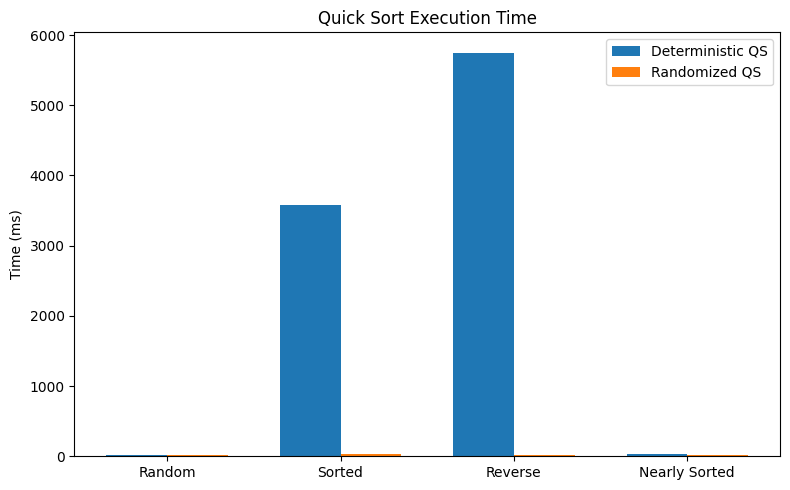

In [1]:
import random
import time
import sys
import matplotlib.pyplot as plt

sys.setrecursionlimit(20000)

comparisons = 0


# Partition Function
def partition(arr, low, high):
    global comparisons

    pivot = arr[high]
    i = low - 1

    for j in range(low, high):
        comparisons += 1
        if arr[j] <= pivot:
            i += 1
            arr[i], arr[j] = arr[j], arr[i]

    arr[i + 1], arr[high] = arr[high], arr[i + 1]
    return i + 1


# Deterministic Quick Sort
def deterministic_quicksort(arr, low, high):
    if low < high:
        pi = partition(arr, low, high)
        deterministic_quicksort(arr, low, pi - 1)
        deterministic_quicksort(arr, pi + 1, high)


# Randomized Quick Sort
def randomized_quicksort(arr, low, high):
    if low < high:
        rand_idx = random.randint(low, high)
        arr[rand_idx], arr[high] = arr[high], arr[rand_idx]

        pi = partition(arr, low, high)

        randomized_quicksort(arr, low, pi - 1)
        randomized_quicksort(arr, pi + 1, high)


# Test Function
def run_test(sort_fn, arr):
    global comparisons

    a = arr[:]
    comparisons = 0

    start = time.perf_counter()
    sort_fn(a, 0, len(a) - 1)
    elapsed = (time.perf_counter() - start) * 1000

    return comparisons, elapsed


# -----------------------------
# Generate Test Cases
# -----------------------------
N = 5000

test_cases = {
    "Random": [random.randint(1, 100000) for _ in range(N)],
    "Sorted": list(range(N)),
    "Reverse": list(range(N, 0, -1)),
    "Nearly Sorted": list(range(N))
}

# Slightly shuffle Nearly Sorted array
ns = test_cases["Nearly Sorted"]
for _ in range(N // 20):
    i = random.randint(0, N - 1)
    j = random.randint(0, N - 1)
    ns[i], ns[j] = ns[j], ns[i]


# -----------------------------
# Run Tests
# -----------------------------
results = []

print("-" * 75)
print(f"{'Input Type':<16}{'DQS Comps':>15}{'DQS Time(ms)':>15}{'RQS Comps':>15}{'RQS Time(ms)':>15}")
print("-" * 75)

for case, arr in test_cases.items():
    d_comp, d_time = run_test(deterministic_quicksort, arr)
    r_comp, r_time = run_test(randomized_quicksort, arr)

    results.append((case, d_comp, d_time, r_comp, r_time))

    print(f"{case:<16}{d_comp:>15}{d_time:>15.2f}{r_comp:>15}{r_time:>15.2f}")


# -----------------------------
# Prepare Data for Graphs
# -----------------------------
labels = [x[0] for x in results]

d_comp = [x[1] for x in results]
r_comp = [x[3] for x in results]

d_time = [x[2] for x in results]
r_time = [x[4] for x in results]

x = range(len(labels))
width = 0.35


# -----------------------------
# Comparisons Graph
# -----------------------------
plt.figure(figsize=(8,5))

plt.bar([i - width/2 for i in x], d_comp, width=width, label="Deterministic QS")
plt.bar([i + width/2 for i in x], r_comp, width=width, label="Randomized QS")

plt.xticks(x, labels)
plt.ylabel("Comparisons")
plt.title("Quick Sort Comparison Count")
plt.legend()

plt.tight_layout()
plt.show()


# -----------------------------
# Execution Time Graph
# -----------------------------
plt.figure(figsize=(8,5))

plt.bar([i - width/2 for i in x], d_time, width=width, label="Deterministic QS")
plt.bar([i + width/2 for i in x], r_time, width=width, label="Randomized QS")

plt.xticks(x, labels)
plt.ylabel("Time (ms)")
plt.title("Quick Sort Execution Time")
plt.legend()

plt.tight_layout()
plt.show()